## Using GAN vs VAE to Reconstruct 2D Medical Images for Downstream Classification

In this notebook, we will be going through a learning roadmap for 2D medical image reconstruction using **Generative Adversarial Networks (GANs)** and comparing it with **Variational Autoencoders (VAE)**. We will be using a simple 2D Chest X-ray image, sourced from the PneumoniaMNIST Dataset, consisting of a 28x28 sixed grayscale normal and pneumonia labeled images.

The objective is to compare the difference between the two synthetic outputs of the reconstructive algorithms used.

-------------------------------------

To start off, let's download the dataset and set up some required library:
- medmnist: provides the PneumoniaMNIST dataset
- torch and torchvision: for deep learning framework
- matplotlib: for plotting graphs
- numpy and scipy: for mathematical and computational operations

In [2]:
!pip install medmnist torch torchvision matplotlib numpy scipy --quiet

In [3]:
import torch                              # Core PyTorch: tensors, autograd
import torch.nn as nn                     # Neural network building blocks (Linear, Conv2d, etc.)
import torch.optim as optim               # Optimizers (Adam)
import torchvision.transforms as transforms  # Image preprocessing pipelines
from torch.utils.data import DataLoader   # Batches & shuffles the dataset during training

import medmnist                           
from medmnist import PneumoniaMNIST       

import numpy as np                        
import matplotlib.pyplot as plt           
from scipy import linalg                  

# ── Reproducibility ──────────────────────────────────────────────────────────
# Setting seeds ensures that random operations (weight init, noise sampling, data shuffling) produce the same result every run 
SEED = 42
torch.manual_seed(SEED)   # Seeds PyTorch's random number generator
np.random.seed(SEED)      # Seeds NumPy's random number generator

# ── Device ───────────────────────────────────────────────────────────────────
# Use GPU if available & CPU Fallback
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'MedMNIST version: {medmnist.__version__}')

Using device: cpu
MedMNIST version: 3.0.2


Before we load the data, it is important to note that the value scales (pixel ranges) used in GAN and VAE are different. With GAN it uses Tanh [-1,1] output, but VAE uses Sigmoid [0,1] output. Thus, we need to normalise them accordingly before proceeding to downstream trainings.

In [4]:
'''Transforms'''
# GAN uses Tanh output → normalize images to [-1, 1]
# VAE uses Sigmoid output → keep images in [0, 1]

transform_gan = transforms.Compose([
    # Step 1: Convert PIL image (H×W, uint8 0–255) to float tensor (C×H×W, 0.0–1.0)
    transforms.ToTensor(),
    # Step 2: Shift range from [0,1] → [-1,1]
    # Formula: output = (input - mean) / std = (input - 0.5) / 0.5
    # When input=0.0 → output=-1.0; when input=1.0 → output=+1.0
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform_vae = transforms.Compose([
    # Only need ToTensor — Sigmoid output already spans [0,1]
    transforms.ToTensor()
])

'''Load datasets'''
# Use the official partition, giving a 4,708 train sample size
train_gan = PneumoniaMNIST(split='train', transform=transform_gan, download=True)
train_vae = PneumoniaMNIST(split='train', transform=transform_vae, download=True)

print('=== GAN Dataset (normalized to [-1, 1]) ===')
print(f'Train size : {len(train_gan)}')
print(f'Image shape: {train_gan[0][0].shape}')
print(f'Label shape: {train_gan[0][1].shape}')
print(f'Pixel range: [{train_gan[0][0].min():.3f}, {train_gan[0][0].max():.3f}]')

print()
print('=== VAE Dataset (normalized to [0, 1]) ===')
print(f'Train size : {len(train_vae)}')
print(f'Image shape: {train_vae[0][0].shape}')
print(f'Label shape: {train_vae[0][1].shape}')
print(f'Pixel range: [{train_vae[0][0].min():.3f}, {train_vae[0][0].max():.3f}]')


Using downloaded and verified file: /Users/sunetnanta/.medmnist/pneumoniamnist.npz
Using downloaded and verified file: /Users/sunetnanta/.medmnist/pneumoniamnist.npz
=== GAN Dataset (normalized to [-1, 1]) ===
Train size : 4708
Image shape: torch.Size([1, 28, 28])
Label shape: (1,)
Pixel range: [-1.000, 0.765]

=== VAE Dataset (normalized to [0, 1]) ===
Train size : 4708
Image shape: torch.Size([1, 28, 28])
Label shape: (1,)
Pixel range: [0.000, 0.882]


Now both datasets are imported and normalised to their respective scales. Next, let's plot an overview of the images included in this dataset for a quick visual inspection of the images we will be working on. 

There are two classes in this dataset: normal chest x-rays, and pneumonia chest x-rays.

/var/folders/5d/k7gxx1wn7y156f92kp762f700000gn/T/ipykernel_3973/2440820002.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if len(normal_imgs) < n_per_class and int(label) == 0:
/var/folders/5d/k7gxx1wn7y156f92kp762f700000gn/T/ipykernel_3973/2440820002.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  elif len(pneumonia_imgs) < n_per_class and int(label) == 1:


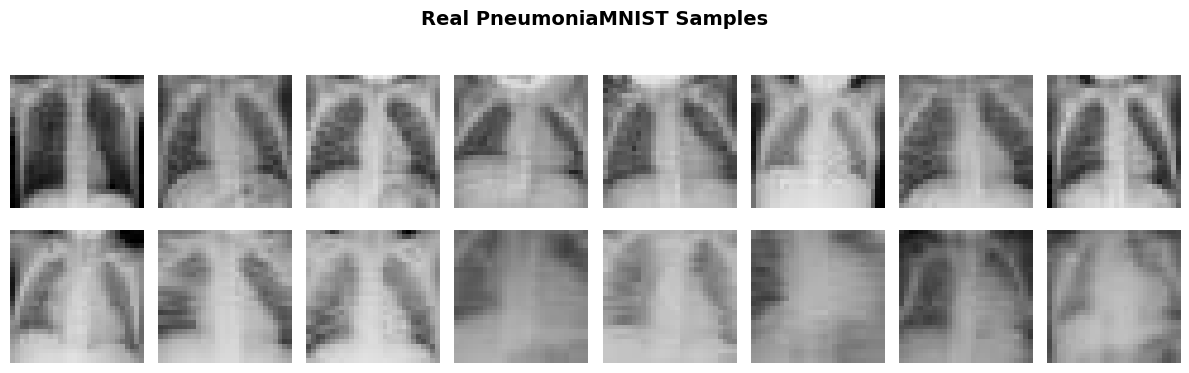

In [5]:
def show_samples(dataset, title, n_per_class=8):
    # start with 8 normal images and 8 pneumonia images
    # the integer of the normal images are labeled as 0 and pneumonia images are labeled as 1 in the original dataset
    normal_imgs, pneumonia_imgs = [], []
    for img, label in dataset:
        if len(normal_imgs) < n_per_class and int(label) == 0:
            normal_imgs.append(img)
        elif len(pneumonia_imgs) < n_per_class and int(label) == 1:
            pneumonia_imgs.append(img)
        # Stop early once we have 8 (as defined) of both
        if len(normal_imgs) == n_per_class and len(pneumonia_imgs) == n_per_class:
            break

    # plot into 2 rows: upper row (normal) and lower row (pneumonia), having n_per_class images in each row
    fig, axes = plt.subplots(2, n_per_class, figsize=(n_per_class * 1.5, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i in range(n_per_class):
        # .squeeze() removes the channel dimension: (1,28,28) → (28,28) for imshow
        # * 0.5 + 0.5 reverses the GAN normalization: [-1,1] → [0,1] for display
        axes[0, i].imshow(normal_imgs[i].squeeze() * 0.5 + 0.5, cmap='gray', vmin=0, vmax=1)
        axes[0, i].axis('off')   # Hide axis ticks and borders
        axes[1, i].imshow(pneumonia_imgs[i].squeeze() * 0.5 + 0.5, cmap='gray', vmin=0, vmax=1)
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Normal',    color='steelblue', fontsize=10)
    axes[1, 0].set_ylabel('Pneumonia', color='tomato',    fontsize=10)
    plt.tight_layout()
    plt.show()

show_samples(train_gan, 'Real PneumoniaMNIST Samples') # should be same on both gan and vae anyways

Now that the import of the datasets are set, let's look at the two algorithms!

For each algorithm, the structure will be as follows:
1. Configuration/ parameters set-up
2. Define architecture (classes i.e. discriminator and generator/ encoder and decoder) and Helper functions
3. Instantiate to create real objects for training
4. Run training

----------------------------------------------------------
## Genetive Adversarial Network (GAN) ##

The GAN works by 2 key elements:
- Generator (takes random noise z -> produce a fake image)
- Discriminator (takes an image -> predict real or fake )

These two elements works to compete each other, therefore forcing both networks to improve.


1. GAN Configuration set-up

In [6]:
GAN_CONFIG = {
    ## latent_dim: length of the random noise vector z fed to the Generator.
    # 100 is a standard choice (higher value for higher variation reperesentation)
    'latent_dim'    : 100,

    ## embed_dim: how many numbers represent each class label after embedding. 
    # prior to this we have a scalar label input (0 or 1 for the two classes)
    # this embedding assign 16 numbers (vectors) instead of 0 or 1 to allow a learning (fine-tuning) of the number using a scaled weight
    # essentially, this turns the class label integers into a class label descriptor 
    'embed_dim'     : 16,

    'n_classes'     : 2, # fixed from dataset: 0=Normal, 1=Pneumonia

    'img_channels'  : 1, # fixed grayscale (1 colour channel)

    'img_size'      : 28, # fixed 28x28 pixels from the dataset

    'batch_size'    : 128,

    'lr'            : 0.0002, # standard choice

    ## Adam optimiser parameters
    'betas'         : (0.5, 0.999), #standard choice

    ## Number of training iteration of the whole dataset
    'epochs'        : 50,

    ## label_smooth: instead of using 1.0 for real image targets, use 0.9 (1.0-0.1).
    'label_smooth'  : 0.1, # prevents overconfidence (saturating the sigmoid to 1.0)
}

2. Architecture Definitions: Generator, Discriminator + Helper functions

In [7]:
class Generator(nn.Module):
    """
    GAN Generator.
    Input : noise z (latent_dim,) + class label (integer)
    Output: fake image (1, 28, 28) with pixel values in [-1, 1] via Tanh

    Process: embed label → concat with noise → FC (Fully Connected/ Dense) layer → reshape to 3D feature map
             → ConvTranspose2d to upsample from 7×7 up to 28×28
    """
    def __init__(self, cfg):
        super().__init__()  # Initialize the parent nn.Module
        self.cfg = cfg

        # maps the class label integer (0 Normal, 1 Pneumonia) -> 16-dim vector
        self.label_emb = nn.Embedding(cfg['n_classes'], cfg['embed_dim'])

        # Total input to FC layer = noise vector + label embedding
        # Precalculates the size of the combined input vector fc_input (required for the FC layer)
        fc_input = cfg['latent_dim'] + cfg['embed_dim']  # 100 + 16 = 116

        ## FC block: maps the 1D combined vector → 1D vector that will be reshaped into a 3D feature map (128 channels × 7×7 spatial) to get an image
        # 7x7 doubles each time as we parse through a convtranspose layer -> with 2 layers -> 28x28 final target image size
        # basically vector -> image
        self.fc = nn.Sequential(
            # Projects 116-dim → 128*7*7 = 6272-dim      
            nn.Linear(fc_input, 128 * 7 * 7),
            # BatchNorm1d normalizes activations across the batch at each feature position.
            # Stabilizes training by keeping activations in a consistent range.
            nn.BatchNorm1d(128 * 7 * 7),
            # ReLU: non-linearity. inplace=True modifies tensor in-place to save memory.
            nn.ReLU(inplace=True)
        )

        ## Convolutional upsampling block: progressively increases spatial resolution
        self.conv = nn.Sequential(
            ## ConvTranspose2d ("deconvolution"): the reverse of a Conv2d.
            # It increases spatial size. With kernel=4, stride=2, pad=1:
            # output_size = (input_size - 1)*stride - 2*padding + kernel = (7-1)*2 - 2 + 4 = 14
            # So: 7×7 → 14×14, and channels: 128 → 64
            ### 1st layer ###
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), #from (128, 7, 7) to (64, 14, 14) ~12,544
            nn.BatchNorm2d(64),   # Normalize across batch per spatial location
            nn.ReLU(inplace=True),
            # Reasoning: (early layers) small spatial -> higher channels needed to capture image *COARSE STRUCTURE*

            ### 2nd layer ###
            # Second upsample: 14×14 → 28×28, channels: 64 → 32
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), #from (64, 14, 14) to (32, 28, 28) ~25,088
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            # Reasoning: (later layers) large spatial to represent fine details -> need lower channels *PRECISE DETAILS*

            ### Final grayscale output ###
            # Final Conv2d (stride=1, no size change): 32 → 1 channel (grayscale).
            # padding=1 with kernel=3 keeps spatial size at 28×28.
            nn.Conv2d(32, cfg['img_channels'], kernel_size=3, stride=1, padding=1), #from (32, 28, 28) to (1, 28, 28)

            # Tanh squashes output to [-1, 1], matching the GAN-normalized training data.
            nn.Tanh()
        )

    # Actually running the convolution
    def forward(self, z, labels):
        emb = self.label_emb(labels)

        # Add noise z and label together
        x = torch.cat([z, emb], dim=1)
        x = self.fc(x)

        # Reshape 1D feature vector into 3D feature map for ConvTranspose
        # -1 means: infer this dimension from the other dimensions (= batch size)
        x = x.view(-1, 128, 7, 7)   # (B, 128, 7, 7)

        # Upsample through ConvTranspose layers → (B, 1, 28, 28)
        return self.conv(x)

For the Generator, we want to **EXPAND** noise vector (116,) → image (28×28),
So we need to use deconvolution through the ConvTranspose2d function

noise → (128, 7, 7) → (64, 14, 14) → (32, 28, 28) → image

For all the convolution/ deconvolution here, we have chosen a filter size of kernel=4, stride=2 and pad=1.
When we run the convolution through our 28x28 pixel images, it will go through the image in this manner (though in this visualisation it is uses the same kernel but on a 14x14 - the real thing should be on a 28x28 pixel image!)

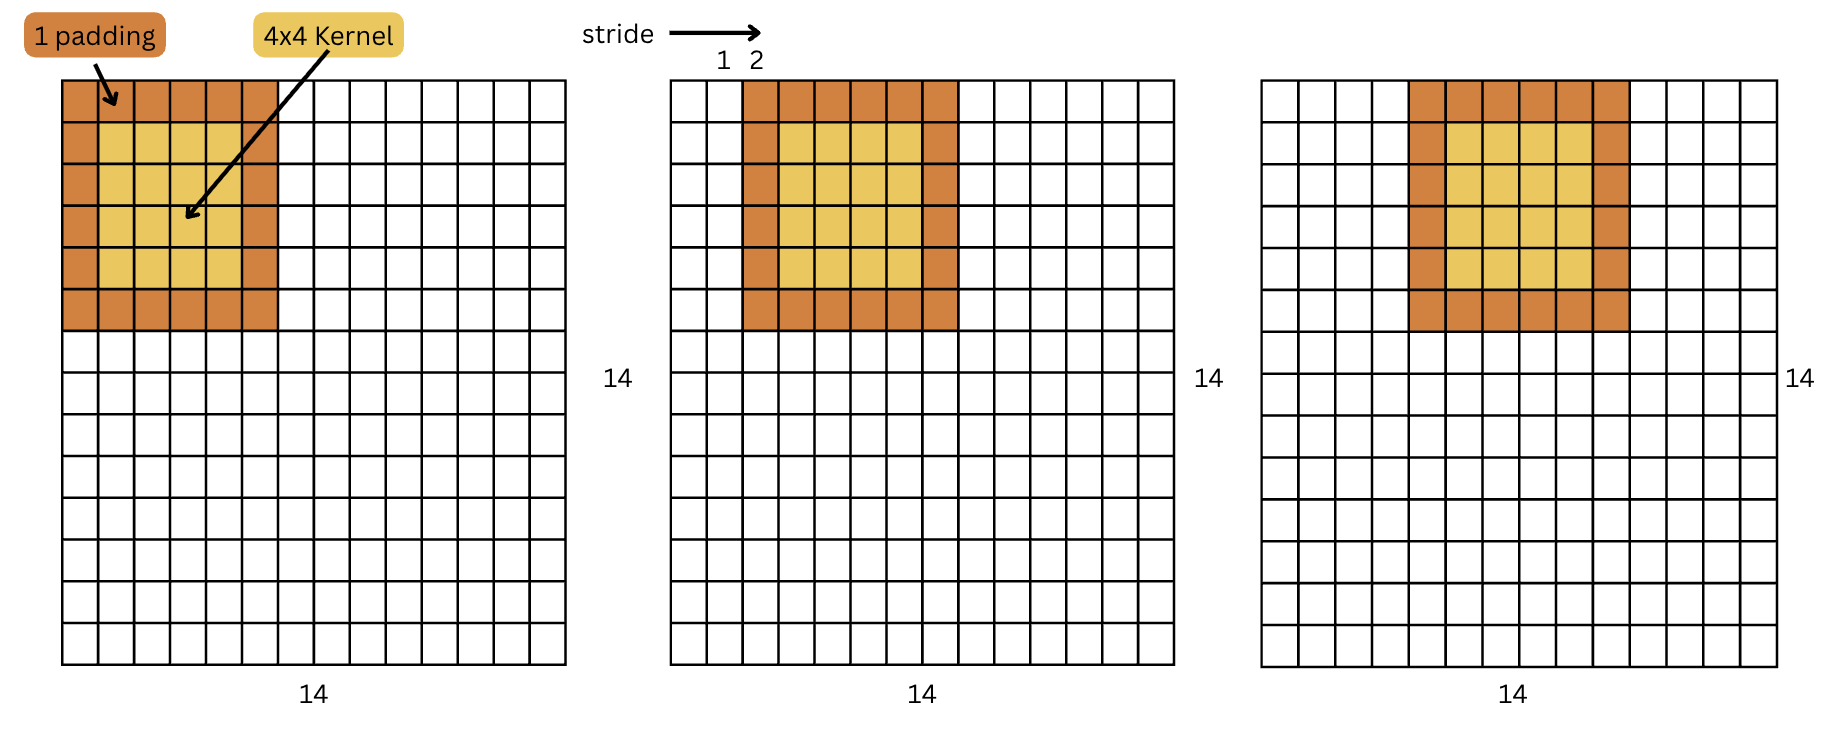

In [8]:
class Discriminator(nn.Module):
    """
    GAN Discriminator.
    Input : image (1, 28, 28) + class label (integer)
    Output: scalar in [0,1] — probability of the image being real

    The label is embedded and projected to a full 28×28 spatial map,
    then concatenated as a second image channel. This way the discriminator
    can detect both "does this look like a real X-ray?" AND
    "does this look like the claimed class?" simultaneously.
    """ 
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        # Project the label into a full spatial map matching the image size.
        # embed_dim = img_size * img_size = 28*28 = 784
        # So label 0 maps to a learned 784-dim vector that will be reshaped to (1,28,28).
        self.label_emb = nn.Embedding(cfg['n_classes'], cfg['img_size'] * cfg['img_size'])

        ## Conv feature extractor. Input has 2 channels: image + label map.
        # Uses LeakyReLU (not ReLU) — standard for discriminators
        self.conv = nn.Sequential(
            # (B, 2, 28, 28) → (B, 64, 13, 13)
            ## From output_size = floor(((input + 2×padding - kernel) / stride) + 1)
            # kernel=4, stride=2, pad=1: output = floor((28 + 2*1 - 4)/2 + 1) = 14
            # (slight asymmetry due to floor) → gives 13 with these exact params
            nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # (B, 64, 13, 13) → (B, 128, 6, 6)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),  # Normalize per channel across batch & spatial dims
            nn.LeakyReLU(0.2, inplace=True),

            # (B, 128, 6, 6) → (B, 256, 3, 3)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.fc = nn.Sequential(
            # Flatten (B, 256, 3, 3) → (B, 256*3*3 = 2304)
            nn.Flatten(),
            # Collapse 2304 features down to a single score
            nn.Linear(256 * 3 * 3, 1),
            # Sigmoid maps the raw score to a probability in [0,1]:
            # 0 = definitely fake, 1 = definitely real
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # Embed label → flatten 784-dim vector → reshape to (B, 1, 28, 28)
        label_map = self.label_emb(labels)  # reshape from this embed label (B, 784)
        label_map = label_map.view(-1, 1, self.cfg['img_size'], self.cfg['img_size'])  # back to the original channel dim (B, 1, 28, 28)

        # Stack image and label map along the channel dimension → (B, 2, 28, 28)
        # Now every conv filter sees both pixel values AND class information
        x = torch.cat([img, label_map], dim=1)

        x = self.conv(x)   # Extract features: (B, 256, 3, 3)
        return self.fc(x) 

As for the discriminator part, it wants to **COMPRESS** and classify the image (28x28) into a single number probability.

This just uses a Conv2d filter over the input and shrink it in spatial size:

(2, 28, 28) -> (64, 14, 14) -> (256, 3, 3) -> single probability score

Now, let's create acutal objects of to prepare for the training using the defined configurations, and with optimisers and loss function properly stated.

The helper function for the reconstructed image visualisation is also added for downstream use.

3. Instantiate the Generator and Discriminator 

In [9]:
G = Generator(GAN_CONFIG).to(DEVICE)
D = Discriminator(GAN_CONFIG).to(DEVICE)

def weights_init(m):
    """
    Custom weight initialization for GAN layers.
    Applied via model.apply(weights_init) which calls this on every sub-module.

    Why not default initialization?
    PyTorch defaults (Kaiming/Xavier) work well for standard classifiers,
    but GANs benefit from smaller initial weights (std=0.02) to keep the
    adversarial dynamics stable at the start of training.
    """
    classname = m.__class__.__name__
    if 'Conv' in classname:
        # Normal distribution with mean=0, std=0.02 for all Conv weight matrices
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        # BatchNorm weights start at 1 (scale) with small noise; bias starts at 0
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# .apply() recursively visits every layer and calls weights_init on it
G.apply(weights_init)
D.apply(weights_init)

# create two separate adam optimisers for each G and D
opt_G = optim.Adam(G.parameters(), lr=GAN_CONFIG['lr'], betas=GAN_CONFIG['betas'])
opt_D = optim.Adam(D.parameters(), lr=GAN_CONFIG['lr'], betas=GAN_CONFIG['betas'])

# create the loss function BCELoss 
# Use 0-1 raw possibility score from the discriminator to compute the loss func of the model (how wrong the probability is)
criterion = nn.BCELoss()
# The smaller the loss value means the discriminator was more accurate (real=real, fake=fake)

# Load the dataset and wraps into desired batch size (as predefined)
gan_loader = DataLoader(train_gan, batch_size=GAN_CONFIG['batch_size'],
                        shuffle=True, num_workers=2, pin_memory=True)

## We also need to make an anchor point to see if our model has improved across iteration
# pull 16 images (8 normal, 8 pneumonia) with random noise vectors 
fixed_noise  = torch.randn(16, GAN_CONFIG['latent_dim']).to(DEVICE) # 16 random noise vecotrs
fixed_labels = torch.tensor([0]*8 + [1]*8).to(DEVICE) # 8 Normal + 8 Pneumonia = 16 images per visualization grid.

In [10]:
## Helper function
def visualize_gan_samples(G, noise, labels, epoch):
    """Generate and display a 2×8 grid of synthetic images from the Generator."""

    # Switch model to eval mode: disables Dropout and uses running stats for BatchNorm
    # (instead of batch stats). Ensures consistent generation (by using stable normalisation statistics through the whole dataset (rather than the 16-image batch))
    G.eval() 
    with torch.no_grad():
        fake = G(noise, labels).cpu()  # Generate images, move to CPU for numpy/matplotlib

    # Switch back to train mode for the next training iteration
    G.train()
    
    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    fig.suptitle(f'GAN — Epoch {epoch}', fontsize=13, fontweight='bold')

    for i in range(16):
        ax  = axes[i // 8, i % 8]   # Row 0 = images 0-7, Row 1 = images 8-15

        img = fake[i].squeeze().numpy() * 0.5 + 0.5
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

        if i % 8 == 0:
            row_label = 'Normal' if i < 8 else 'Pneumonia'
            ax.set_ylabel(row_label, color='steelblue' if i < 8 else 'tomato', fontsize=9)

    plt.tight_layout()
    plt.show()

4. GAN Training Loop

Here is the actual training where we run the GAN training as configured and predefined by the previous blocks.

Starting GAN training...
 Epoch |   Loss D |   Loss G
------------------------------
     1 |   0.9008 |   1.8389


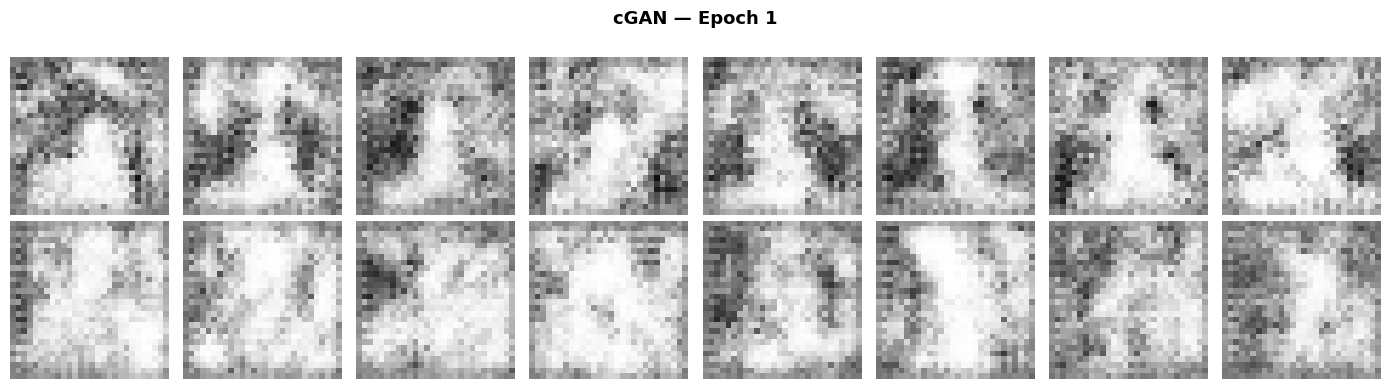

    10 |   1.1511 |   1.1990


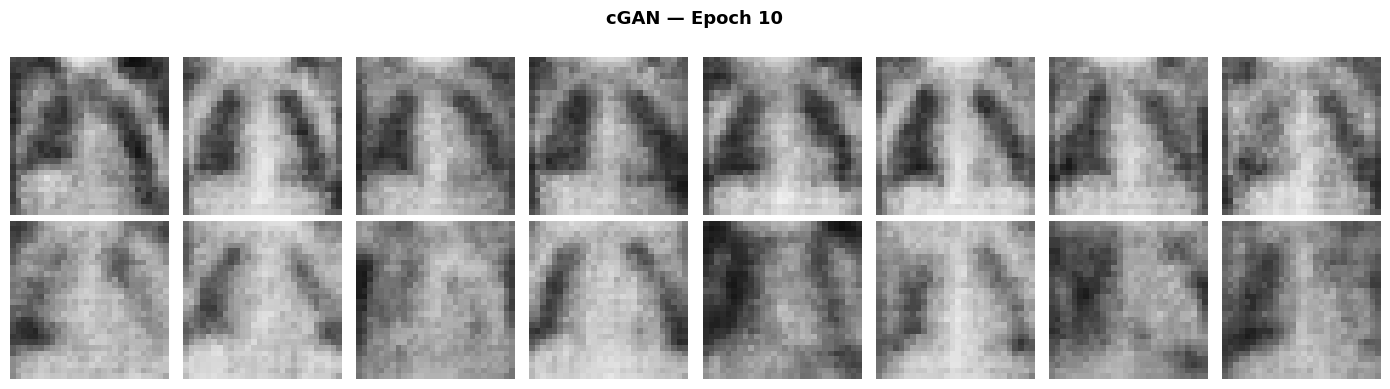

    20 |   1.1705 |   1.1253


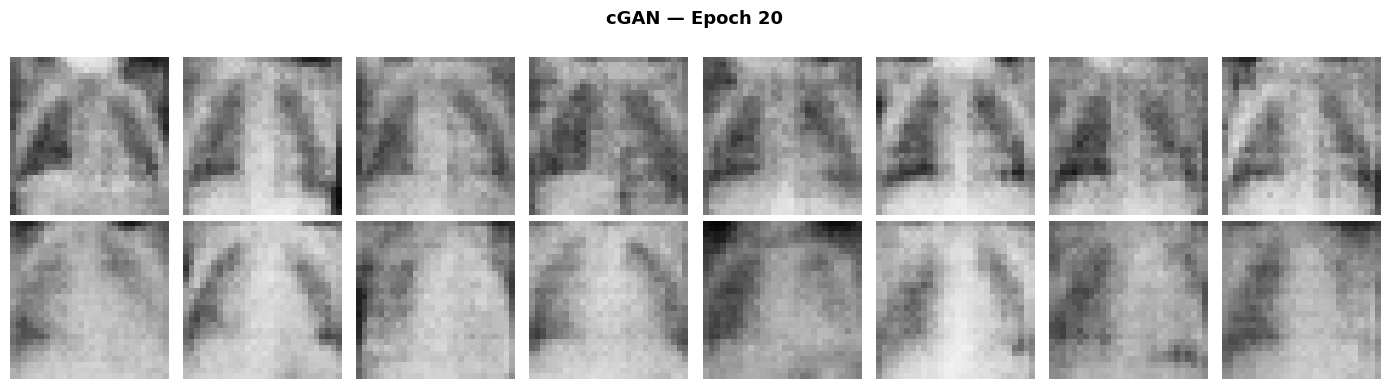

    30 |   1.1705 |   1.1733


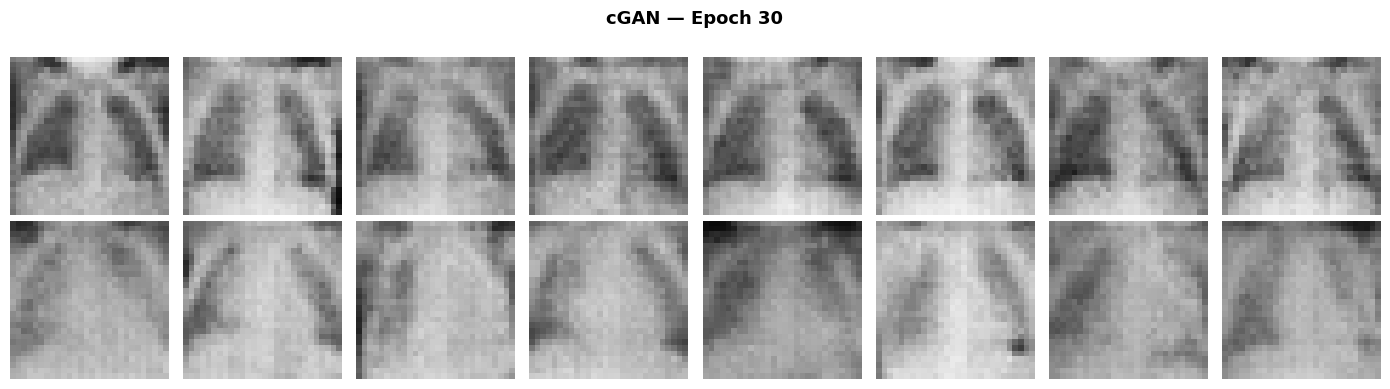

    40 |   1.1651 |   1.1799


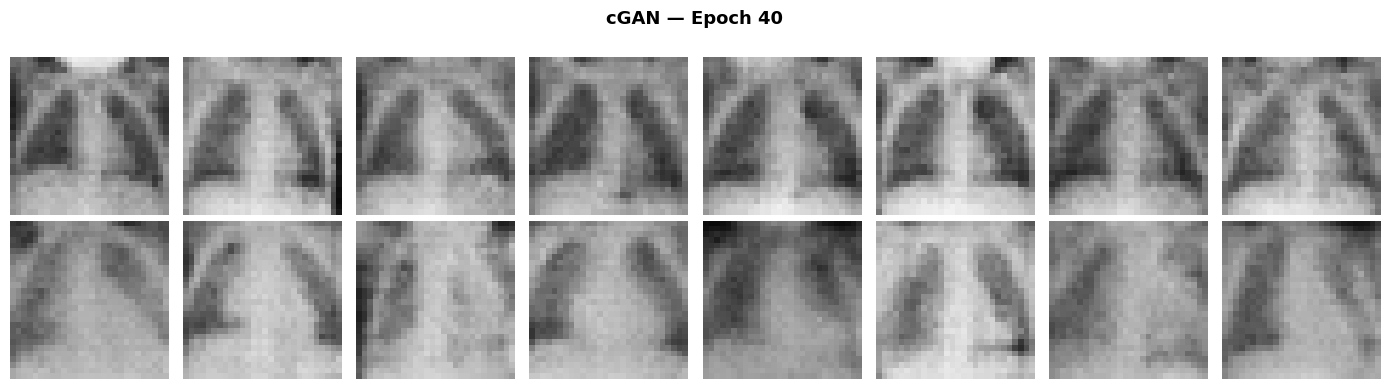

    50 |   1.1793 |   1.1929


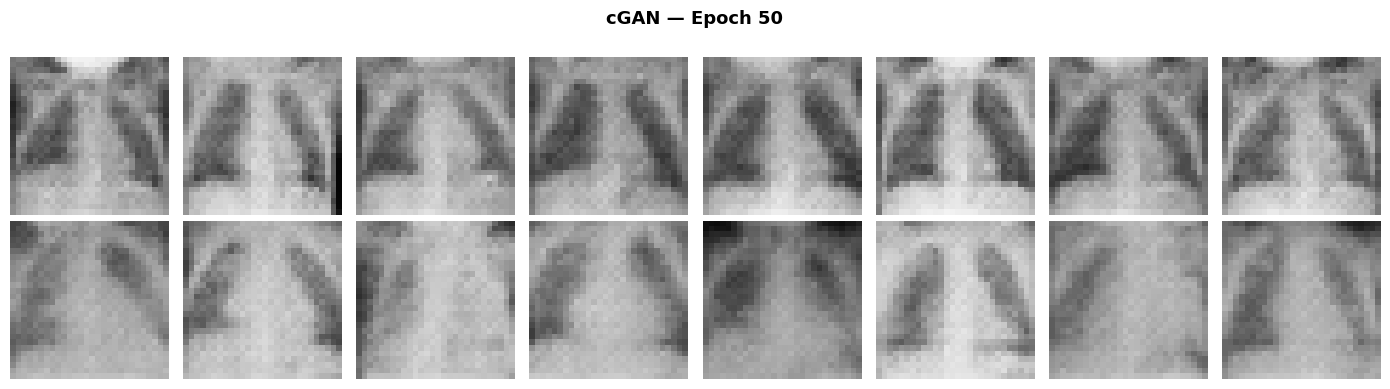

GAN training complete.


In [11]:
''' GAN Training Loop '''

# Track per-epoch average losses for plotting later
gan_losses_G, gan_losses_D = [], []

# Smoothing factor: real image targets = 1.0 - 0.1 = 0.9
smooth = GAN_CONFIG['label_smooth']

print('Starting GAN training...')
print(f"{'Epoch':>6} | {'Loss D':>8} | {'Loss G':>8}")
print('-' * 30)

for epoch in range(1, GAN_CONFIG['epochs'] + 1):
    # Accumulate losses across all batches in this epoch, then average
    epoch_loss_D, epoch_loss_G, n_batches = 0, 0, 0

    for real_imgs, labels in gan_loader:
        B = real_imgs.size(0)  # Actual batch size (last batch may be smaller) #real_imgs have (B,channels,H,W)

        real_imgs = real_imgs.to(DEVICE)
        labels = labels.squeeze().long().to(DEVICE)

        # Create target tensors for the loss function:
        # Real images get target 0.9 (label smoothing) instead of 1.0 (will lead to D overconfidence and the model could stop learning)
        # Fake images get target 0.0
        real_targets = torch.full((B, 1), 1.0 - smooth, device=DEVICE)  # 0.9
        fake_targets = torch.zeros(B, 1, device=DEVICE)                  # 0.0

        # ════════════════════════════════════════════════════════════════════
        # STEP 1: Train Discriminator
        # Goal: correctly classify real images as real AND fake images as fake.
        # Loss_D = BCE(D(real), 0.9) + BCE(D(fake), 0.0)
        # ════════════════════════════════════════════════════════════════════

        # Remove gradient accum from the previous batch — PyTorch accumulates by default
        # so that we can calculate new gradient specifc to this batch and then update D weights (gives independent update to D weight)
        opt_D.zero_grad() 

        ###1. D wants to detect real image and give it a 0.9 (real_target = 0.9)
        loss_real = criterion(D(real_imgs, labels), real_targets)

        # Generate a batch of fake images from random noise
        z = torch.randn(B, GAN_CONFIG['latent_dim'], device=DEVICE)
        fake_imgs = G(z, labels).detach()
        ###2. D also wants to detect fake image and give it a 0 (fake_target = 0)
        loss_fake = criterion(D(fake_imgs, labels), fake_targets)

        # TOTAL discriminator loss is the sum of both terms
        loss_D = loss_real + loss_fake

        # Backpropagation: Compute gradients for D's parameters
        loss_D.backward()
        # Update D param
        opt_D.step()

        # ════════════════════════════════════════════════════════════════════
        # STEP 2: Train Generator
        # Goal: produce images that fool D into outputting ~1 ("this is real").
        # Loss_G = BCE(D(fake), 1.0)  ← G wants D to think fakes are real
        # ════════════════════════════════════════════════════════════════════

        opt_G.zero_grad() #Also remove gradient accum for G here

        # Generate a fresh batch of noise — different from the D training noise
        z = torch.randn(B, GAN_CONFIG['latent_dim'], device=DEVICE)
        fake_imgs = G(z, labels)  # No detach here — gradients must flow into G

        # G wants D to classify its fakes as real → use ONLY real_targets (0.9) as target
        # If D outputs 0.1 for a fake, loss is high → G gets large gradient to improve
        # If D outputs 0.9 for a fake, loss is low  → G successfully fooled D
        loss_G = criterion(D(fake_imgs, labels), real_targets) # G tries to generate 0.9 real

        loss_G.backward()  # Gradients flow through D, then through G
        opt_G.step()       # Update only G's parameters

        # Accumulate scalar loss values (.item() extracts the float from a 0-dim tensor)
        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()
        n_batches    += 1

    # Average loss over all batches in this epoch
    avg_D = epoch_loss_D / n_batches
    avg_G = epoch_loss_G / n_batches
    gan_losses_D.append(avg_D)
    gan_losses_G.append(avg_G)

    # Print progress and visualize generated images every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6} | {avg_D:>8.4f} | {avg_G:>8.4f}')
        visualize_gan_samples(G, fixed_noise, fixed_labels, epoch)

print('GAN training complete.')

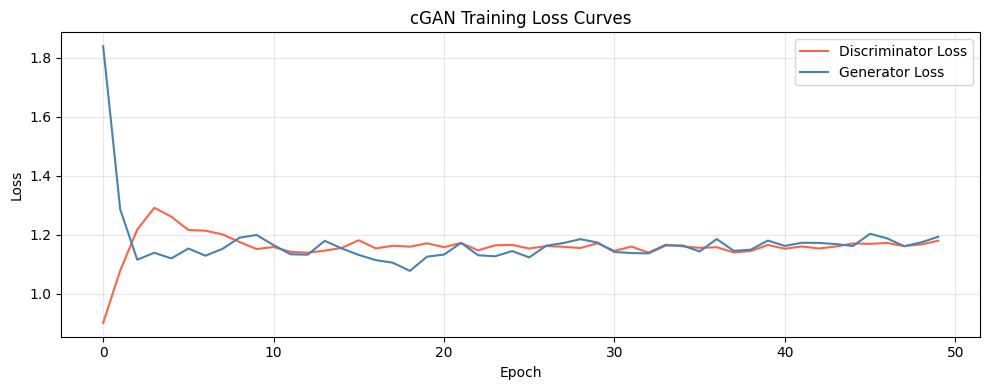

In [ ]:
'''Plot GANs Training Loss Curves'''
plt.figure(figsize=(10, 4))

# Plot D and G loss curves on the same axis to see the adversarial balance
plt.plot(gan_losses_D, label='Discriminator Loss', color='tomato')
plt.plot(gan_losses_G, label='Generator Loss',     color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Loss Curves')
plt.legend()
plt.grid(alpha=0.3) 
plt.tight_layout()
plt.show()

Loss Curve Graph Interpretation:

Both the Discriminator (D) and the Generator (G) starts at random. 

The D has higher loss since it works to discriminate fake and real images but with initial random weights, it cannot efficiently classify the images yet.

The G on the other hand, also starts at random and producing images with random noises that is not good at being a "fake penumonia image yet" so they get catched by the D easily. This event when they are TOO EASILY caught means they start with a low loss fx.

After several iterations of the 50 epochs, the G and D both learns from the random initialisation 
- D works better to classify => lower loss fx
- G works better to generate fakes and fool D => higher loss fx

and at a certain point then both oscillate together as they compete!

-----------------------------------------
## Variational Autoencoders (VAE)

unlike the GAN with two competing models, VAE runs in a single pipeline. It uses compression into probability-distributed latent spaces and decompression back to reconstruct images.

Where the:
1. Encoder (compresses image into latent space)
2. Decoder (reconstruct image from latent space back to a new reconstructed image)

However, it is important to note that since there is an inclusion of latent spaces which must be learned, the loss function would have to also include the learning of that latent space as well.

Therefore,
**Loss function = BCE + β × KL Divergence**

Same as before, we will set-up the configurations first.

1. VAE Configuration Set-up

In [13]:
VAE_CONFIG = {
    # latent_dim: size of the latent space z.
    # Unlike the GAN's noise (100-dim), the VAE latent space is structured — it's regularized by KL divergence to follow N(0,I)
    # 64 dims gives enough capacity to represent chest X-ray variation
    'latent_dim'  : 64,

    # embed_dim: same role as in GAN 
    'embed_dim'   : 16,

    'n_classes'   : 2,
    'img_channels': 1,
    'img_size'    : 28,
    'batch_size'  : 128,
    # all fixed and same as GAN

    # lr: VAEs can use a higher learning rate than GANs (1e-3 vs 2e-4)
    # because there's no adversarial instability — just a single stable loss.
    'lr'          : 1e-3,

    'epochs'      : 50, # same as GAN

    # beta: weight applied to the KL divergence term in the loss.
    # standard value chosen
    'beta'        : 1.0,
}

2. Architecture Definitions: Encoder, Decoder + Helper functions

The VAE encoder works to convert the images (1,28,28) into a latent space of mu (64) and log_var (64)

In [14]:
class Encoder(nn.Module):
    """
    VAE Encoder: maps a real image + label → latent distribution parameters (μ, log σ²).

    The encoder does NOT output a single point in latent space.
    It outputs TWO vectors: mu (mean) and log_var (log variance).
    Together they define a Gaussian distribution N(mu, exp(log_var)).
    We sample z from this distribution during training.
    """
    def __init__(self, cfg):
        super().__init__()

        # Same label embedding as in GAN: integer class → 16-dim vector
        self.label_emb = nn.Embedding(cfg['n_classes'], cfg['embed_dim'])

        # Convolutional feature extractor — progressively downsample imagewhile increasing channel depth (classic encoder pattern)
        self.conv = nn.Sequential(
            # (B, 1, 28, 28) → (B, 32, 14, 14): halve spatial, 1→32 channels
            nn.Conv2d(1, 32,  kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),

            # (B, 32, 14, 14) → (B, 64, 7, 7): halve spatial again, 32→64 channels
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),  # Stabilizes training at this deeper layer
            nn.ReLU(inplace=True),

            # (B, 64, 7, 7) → (B, 128, 4, 4): kernel=3,stride=2,pad=1 → floor((7+2-3)/2+1)=4
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        # After conv: spatial is 4×4, 128 channels → 128*4*4 = 2048 features

        ## Shared FC layer: combines image features with class label
        # Input: 2048 (conv output) + 16 (label embedding) = 2064
        self.fc = nn.Sequential(
            nn.Linear(128 * 4 * 4 + cfg['embed_dim'], 512),
            nn.ReLU(inplace=True)
        )

        # Two separate output heads — both read from the same 512-dim shared representation
        ## fc_mu:      outputs the mean vector μ of the latent Gaussian
        ## fc_log_var: outputs log(σ²) — using log variance (not σ) for numerical stability
        #             (variance must be positive, but log variance can be any real number)
        self.fc_mu      = nn.Linear(512, cfg['latent_dim'])
        self.fc_log_var = nn.Linear(512, cfg['latent_dim'])

    def forward(self, img, labels):
        # Extract convolutional features and flatten to 1D
        x = self.conv(img)               # (B, 128, 4, 4)
        x = x.view(img.size(0), -1)      # (B, 2048) — flatten spatial dims

        # Get label embedding and fuse with image features
        emb = self.label_emb(labels)     # (B, 16)
        x   = self.fc(torch.cat([x, emb], dim=1))  # (B, 512)

        ## Return two things: both mu and log var distribution parameters — NOT a sampled point
        return self.fc_mu(x), self.fc_log_var(x)   # (B, 64) each

and the VAE decoder works oppositely, decompressing latent point z (64) back to image (1,28,28)


In [15]:
class Decoder(nn.Module):
    """
    VAE Decoder: maps a latent point z + label → reconstructed image.

    Mirror of the Encoder — expands back from latent space to image space.
    At generation time: sample z ~ N(0,I) and feed it here directly
    (bypassing the Encoder entirely).
    """
    def __init__(self, cfg):
        super().__init__()

        self.label_emb = nn.Embedding(cfg['n_classes'], cfg['embed_dim'])

        # FC block: project z + label embedding into a 3D feature map
        # Input: 64 (latent_dim) + 16 (embed_dim) = 80
        self.fc = nn.Sequential(
            nn.Linear(cfg['latent_dim'] + cfg['embed_dim'], 512),
            nn.ReLU(inplace=True),
            # Project to the size needed for the first ConvTranspose layer
            # 128 channels × 4×4 spatial = 2048 values
            nn.Linear(512, 128 * 4 * 4),
            nn.ReLU(inplace=True)
        )

        # ConvTranspose upsampling — mirrors the Encoder's downsampling
        self.conv = nn.Sequential(
            # (B, 128, 4, 4) → (B, 64, 7, 7)
            # kernel=3, stride=2, pad=1: output = (4-1)*2 - 2 + 3 = 7
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # (B, 64, 7, 7) → (B, 32, 14, 14)
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # (B, 32, 14, 14) → (B, 1, 28, 28): final output is grayscale
            nn.ConvTranspose2d(32, cfg['img_channels'], kernel_size=4, stride=2, padding=1),

            # Sigmoid maps output to [0,1], matching the [0,1]-normalized training images (unlink Tanh [-1,1] in GANs)
            # (VAE transform_vae uses only ToTensor, not the [-1,1] normalization)
            nn.Sigmoid()
        )

    def forward(self, z, labels):
        emb = self.label_emb(labels)                     # (B, 16)
        x   = self.fc(torch.cat([z, emb], dim=1))        # (B, 128*4*4 = 2048)
        x   = x.view(-1, 128, 4, 4)                      # Reshape to 3D feature map
        return self.conv(x)                              # (B, 1, 28, 28) in [0,1]

Now for the helper functions in VAE, we need certain helpers to allow for the downstream training.

In [16]:
def reparameterize(mu, log_var):
    """
    Reparameterization trick — the key innovation that makes VAEs trainable.

    Problem: to sample z out of N(mu, sigma²) is a random operation.
    Random operations have no gradient — backpropagation would stop at the sample and the encoder cannot be trained.

    Solution: instead of sampling directly from  N(mu, sigma²) -> rewrite z = mu + sigma * epsilon, where ε ~ N(0, 1)
    Now the randomness the moved to the ε (epsilon), which can be sampled externally from the standard normal

    Now:
    - epsilon is sampled externally (no gradient needed)
    - mu and sigma are deterministic outputs of the Encoder
    - Gradients flow through mu and sigma normally
    """
    # std = exp(0.5 * log_var) = exp(log(sigma)) = sigma
    # We use log_var instead of var because log_var can be negative (unconstrained), while variance must be positive. exp() ensures positivity.
    std = torch.exp(0.5 * log_var)

    # Sample epsilon from standard normal — same shape as std
    # torch.randn_like creates a tensor of the same shape/dtype/device
    epsilon = torch.randn_like(std)

    # z = mu + sigma * epsilon
    # This is equivalent to sampling from N(mu, sigma²) but is differentiable
    return mu + std * epsilon


def vae_loss(recon_img, real_img, mu, log_var, beta=1.0):
    """
    VAE Loss Function = Reconstruction Loss + β * KL Divergence

    This is the ELBO (Evidence Lower Bound) — maximizing ELBO is equivalent
    to maximizing the likelihood of the data under the model.

    Reconstruction Loss (BCE): #reconstruction accuracy
        How well does the Decoder recreate the original input?
        Uses binary cross entropy treating each pixel as an independent Bernoulli.
        reduction='sum' sums over all pixels; we then divide by batch size B
        to get a per-image average (not per-pixel, which would be too small).

    KL Divergence: #latent space organisation
        Measures how far the learned latent distribution N(mu, exp(log_var))
        is from the prior N(0, I). Acts as a regularizer:
        - Forces latent codes to stay near the origin (prevents "holes" in latent space)
        - Ensures interpolation between latent points gives valid images
        Closed-form solution: -0.5 * sum(1 + log_var - mu² - exp(log_var))
    """
    B = real_img.size(0)  # Batch size for normalization

    # Reconstruction: pixel-wise BCE between decoder output and original image
    # Both recon_img and real_img are in [0,1] (Sigmoid output, ToTensor input)
    recon_loss = nn.functional.binary_cross_entropy(recon_img, real_img, reduction='sum') / B

    # KL divergence between N(mu, var) and N(0,1)
    # The minus sign comes from the ELBO derivation — we minimize loss, so
    # minimizing (-KL) = maximizing KL. The formula below gives a positive value
    # that decreases as the latent distribution approaches N(0,1).
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / B

    # beta scales the trade-off: higher beta = more regularization, less reconstruction detail
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

In [18]:
def visualize_vae_samples(Dec, z, labels, epoch):
    """Generate and display a 2×8 grid of synthetic images from the VAE Decoder."""

    Dec.eval()
    with torch.no_grad():
        fake = Dec(z, labels).cpu()  # VAE output is already in [0,1] via Sigmoid

    Dec.train()

    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    fig.suptitle(f'VAE — Epoch {epoch}', fontsize=13, fontweight='bold')

    for i in range(16):
        ax = axes[i // 8, i % 8]  # Row 0 = images 0-7, Row 1 = images 8-15

        img = fake[i].squeeze().numpy()
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

        if i % 8 == 0:
            row_label = 'Normal' if i < 8 else 'Pneumonia'
            ax.set_ylabel(row_label, color='steelblue' if i < 8 else 'tomato', fontsize=9)

    plt.tight_layout()
    plt.show()

3. Instantiation of VAE elements

In [17]:
# Instantiate Encoder and Decoder and move to device
E   = Encoder(VAE_CONFIG).to(DEVICE)
Dec = Decoder(VAE_CONFIG).to(DEVICE)

# Unlike GAN which needs two separate optimisers, we need only 1 optimer for the VAE
opt_VAE = optim.Adam(list(E.parameters()) + list(Dec.parameters()), lr=VAE_CONFIG['lr'])

# ReduceLROnPlateau: automatically reduces learning rate when total loss stops improving.
# patience=5: wait 5 epochs of no improvement before reducing
# factor=0.5: multiply LR by 0.5 (halve it) when triggered
# verbose=True: print a message when LR is reduced
scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt_VAE, patience=5, factor=0.5, verbose=True)

# DataLoader for the [0,1]-normalized dataset (used by VAE)
vae_loader = DataLoader(train_vae, batch_size=VAE_CONFIG['batch_size'],
                        shuffle=True, num_workers=2, pin_memory=True)

# Fixed latent vectors (created once) to track VAE improvement across epochs
# We sample from N(0,I) — this is what we also sample from at generation time
fixed_z_vae = torch.randn(16, VAE_CONFIG['latent_dim']).to(DEVICE) # 16 random latent vectors
fixed_l_vae = torch.tensor([0]*8 + [1]*8).to(DEVICE)  # 8 Normal, 8 Pneumonia
# This is the same logic as the anchor point images we had in GANs

/opt/anaconda3/envs/bcienv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


4. Actual Training Loop

Starting VAE training...
 Epoch |    Total |    Recon |       KL
----------------------------------------
     1 |   526.56 |   524.80 |     1.76


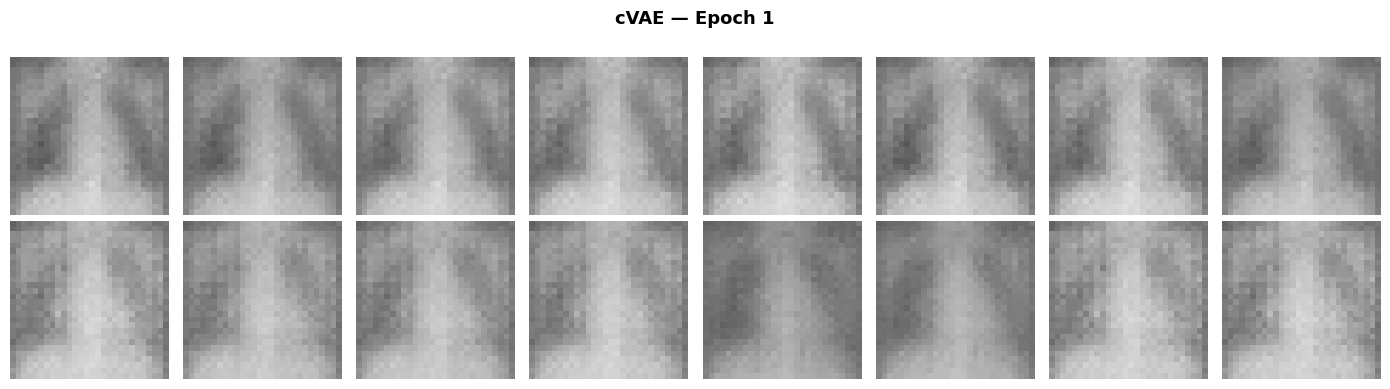

    10 |   506.29 |   503.98 |     2.31


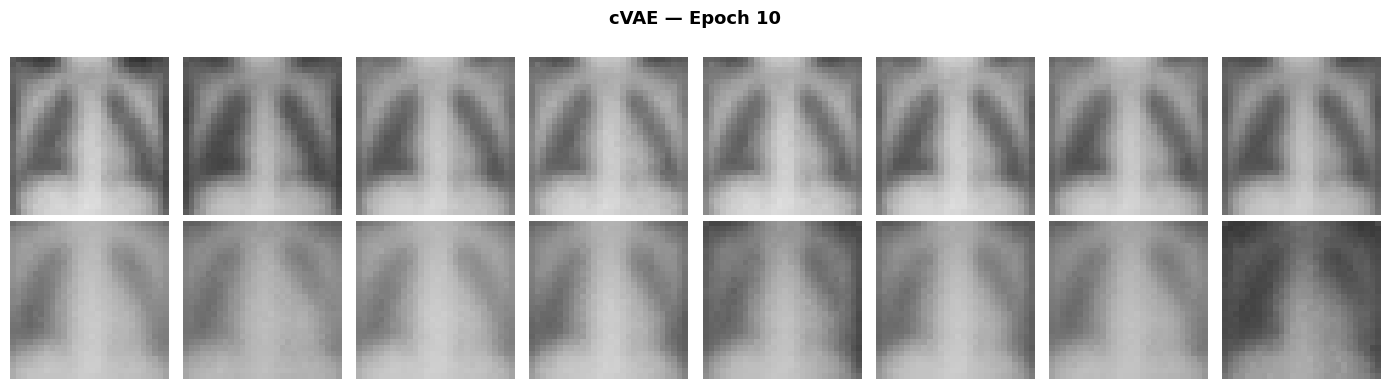

    20 |   505.17 |   501.93 |     3.24


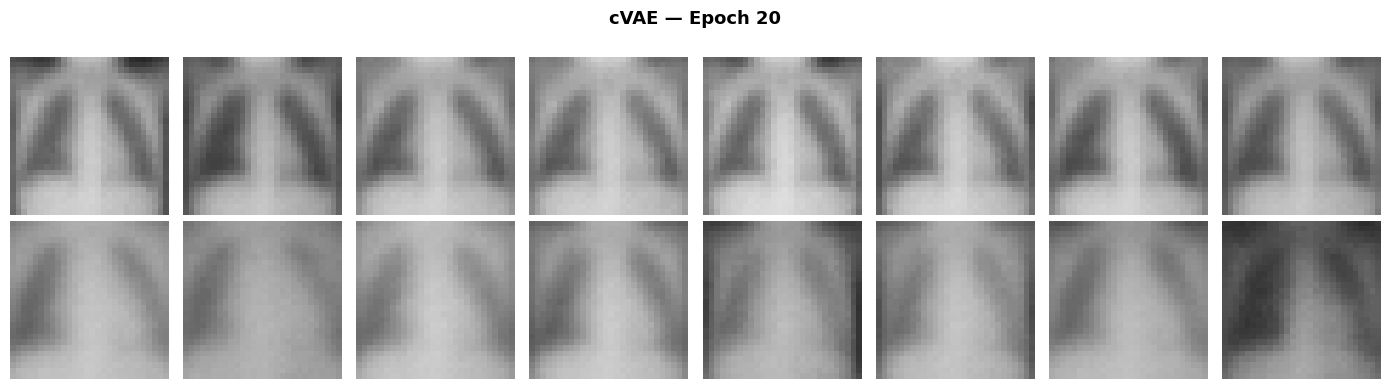

    30 |   504.44 |   500.92 |     3.51


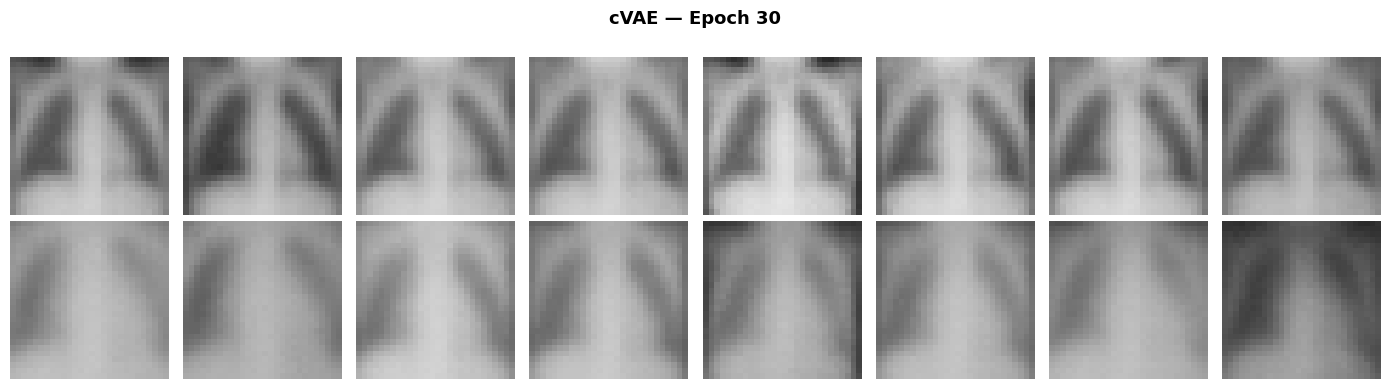

    40 |   503.88 |   500.02 |     3.86


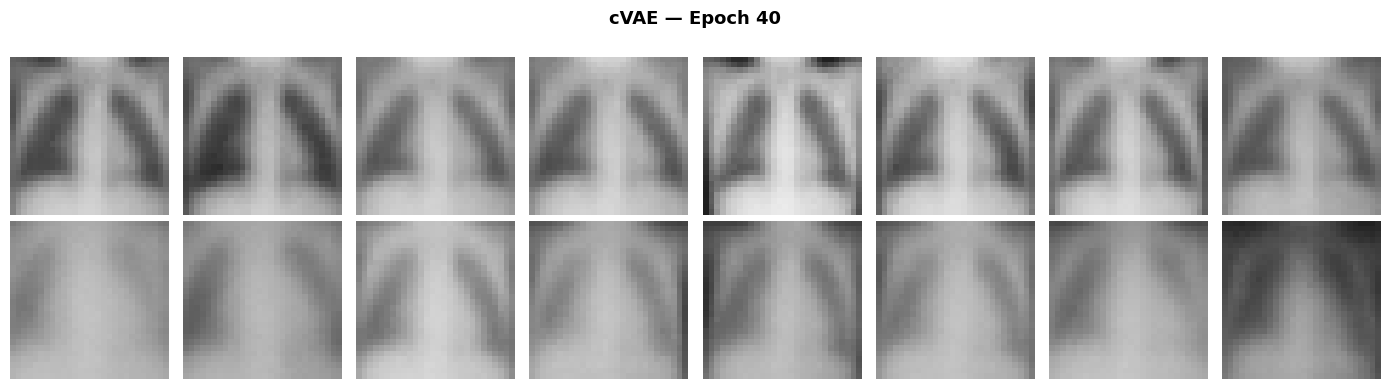

    50 |   503.57 |   499.35 |     4.21


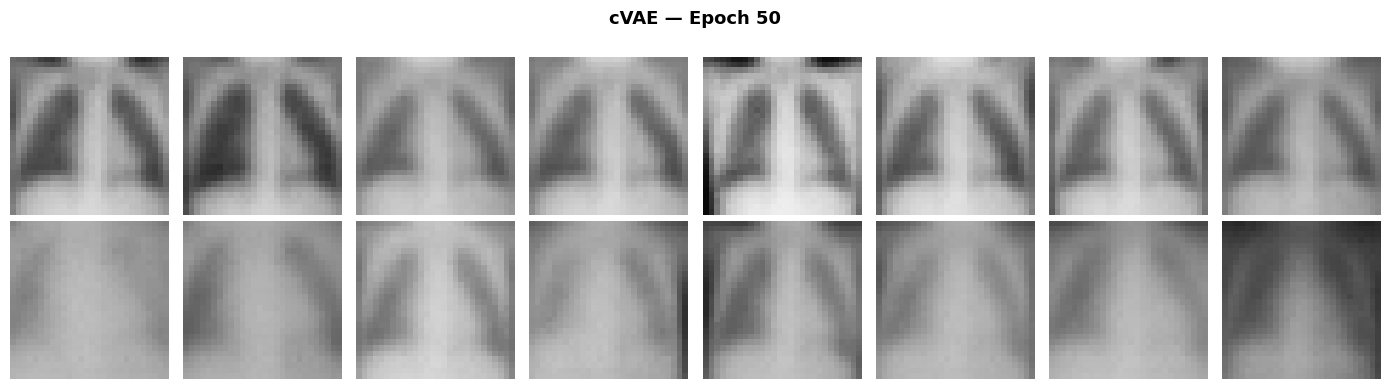

VAE training complete.


In [19]:
'''VAE Training Loop'''
# Track all three loss components separately for diagnostic plotting
vae_total_losses, vae_recon_losses, vae_kl_losses = [], [], []

print('Starting VAE training...')
print(f"{'Epoch':>6} | {'Total':>8} | {'Recon':>8} | {'KL':>8}")
print('-' * 40)

for epoch in range(1, VAE_CONFIG['epochs'] + 1):
    # Set both Encoder and Decoder to training mode
    E.train(); Dec.train()
    total_sum, recon_sum, kl_sum, n_batches = 0, 0, 0, 0

    for real_imgs, labels in vae_loader:
        real_imgs = real_imgs.to(DEVICE)
        labels    = labels.squeeze().long().to(DEVICE)

        # ── Forward pass through the full VAE ────────────────────────────────

        # 1. Encode: compress image + label into distribution parameters
        #    mu and log_var are both shape (B, latent_dim)
        mu, log_var = E(real_imgs, labels)

        # 2. Sample: draw a latent point z using the reparameterization trick
        #    z is shape (B, latent_dim) — one point per image in the batch
        z = reparameterize(mu, log_var)

        # 3. Decode: reconstruct the image from the sampled latent point
        #    recon_imgs is shape (B, 1, 28, 28) in [0,1]
        recon_imgs = Dec(z, labels)

        # ── Compute loss ──────────────────────────────────────────────────────
        # loss  = total (what we backprop through)
        # recon = reconstruction term (how well Decoder reproduced input)
        # kl    = KL divergence term (how close latent dist is to N(0,I))
        loss, recon, kl = vae_loss(recon_imgs, real_imgs, mu, log_var, VAE_CONFIG['beta'])

        # ── Backward pass ──────────────────────────────────────────────────────
        opt_VAE.zero_grad()  # Clear gradients from previous batch
        loss.backward()      # Compute gradients for ALL VAE parameters (E + Dec)
        opt_VAE.step()       # Update all parameters with Adam

        total_sum += loss.item()
        recon_sum += recon.item()
        kl_sum    += kl.item()
        n_batches += 1

    # average the training throughout all batches and append to update
    avg_total = total_sum / n_batches
    avg_recon = recon_sum / n_batches
    avg_kl    = kl_sum    / n_batches

    vae_total_losses.append(avg_total)
    vae_recon_losses.append(avg_recon)
    vae_kl_losses.append(avg_kl)

    # Pass the total loss to the scheduler.
    # If it hasn't improved for 5 epochs, LR will be halved automatically.
    scheduler.step(avg_total)

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6} | {avg_total:>8.2f} | {avg_recon:>8.2f} | {avg_kl:>8.2f}')
        visualize_vae_samples(Dec, fixed_z_vae, fixed_l_vae, epoch)

print('VAE training complete.')

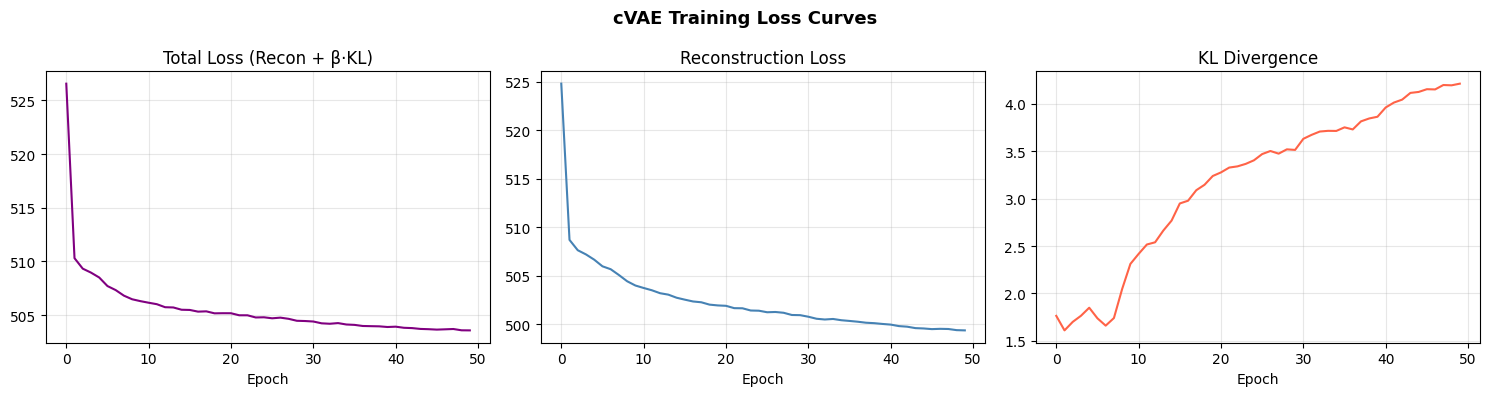

In [20]:
'''Plot VAE Training Loss Curves'''
# Three subplots
# 1.Total Loss (Recon+β·KL)
# 2. Reconstruction Loss
# 3. KL Divergence
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(vae_total_losses, color='purple')
axes[0].set_title('Total Loss (Recon + β·KL)')
axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)

axes[1].plot(vae_recon_losses, color='steelblue')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch'); axes[1].grid(alpha=0.3)

axes[2].plot(vae_kl_losses, color='tomato')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)

plt.suptitle('VAE Training Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Loss Curve Graph Interpretation:

- The Total Loss and Reconstruction loss should decrease steadily and the model improves reconstruction
- KL Divergence should increase as the model learns the latent space

----------------------------------------------------------------
## Comparison of Outputs in GANs and VAE

Now that we have trained both algorithms, 50 epochs each, let's plot to compare the reconstruction outcome of the trainings.

In [21]:
def generate_gan(n=16, label_val=0):
    """Generate n images from the trained GAN Generator for a given class."""
    G.eval()
    with torch.no_grad():
        # Sample random noise from N(0,I) — the Generator's input
        z  = torch.randn(n, GAN_CONFIG['latent_dim']).to(DEVICE)
        # Create a batch of identical labels (all same class)
        lb = torch.full((n,), label_val, dtype=torch.long, device=DEVICE)
        imgs = G(z, lb).cpu()
    G.train()
    # Denormalize: GAN output is in [-1,1], convert to [0,1] for display and metrics
    return imgs * 0.5 + 0.5

def generate_vae(n=16, label_val=0):
    """Generate n images from the trained VAE Decoder for a given class."""
    Dec.eval()
    with torch.no_grad():
        # Sample from the prior p(z) = N(0,I) — what the KL term trained the
        # Encoder to match. This is the correct distribution to sample from
        # when generating new images (bypassing the Encoder).
        z  = torch.randn(n, VAE_CONFIG['latent_dim']).to(DEVICE)
        lb = torch.full((n,), label_val, dtype=torch.long, device=DEVICE)
        imgs = Dec(z, lb).cpu()
    Dec.train()
    return imgs  # VAE output is already in [0,1] via Sigmoid

def get_real(dataset, label_val=0, n=16):
    """Fetch n real images of a given class from the GAN-normalized dataset."""
    imgs = []
    for img, label in dataset:
        if int(label) == label_val:
            # Denorm from GAN's [-1,1] back to [0,1] for fair comparison
            imgs.append(img * 0.5 + 0.5)
        if len(imgs) == n:
            break
    return torch.stack(imgs)  # Stack list of tensors into a single (n,1,28,28) tensor

/var/folders/5d/k7gxx1wn7y156f92kp762f700000gn/T/ipykernel_3973/569171838.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if int(label) == label_val:


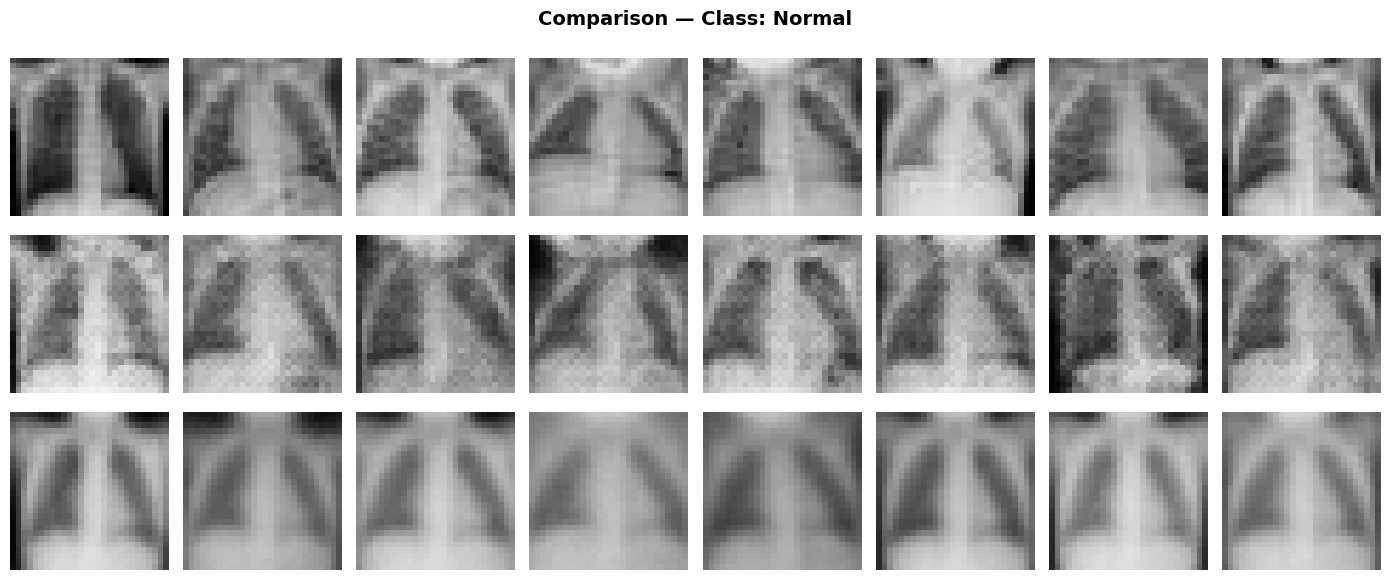

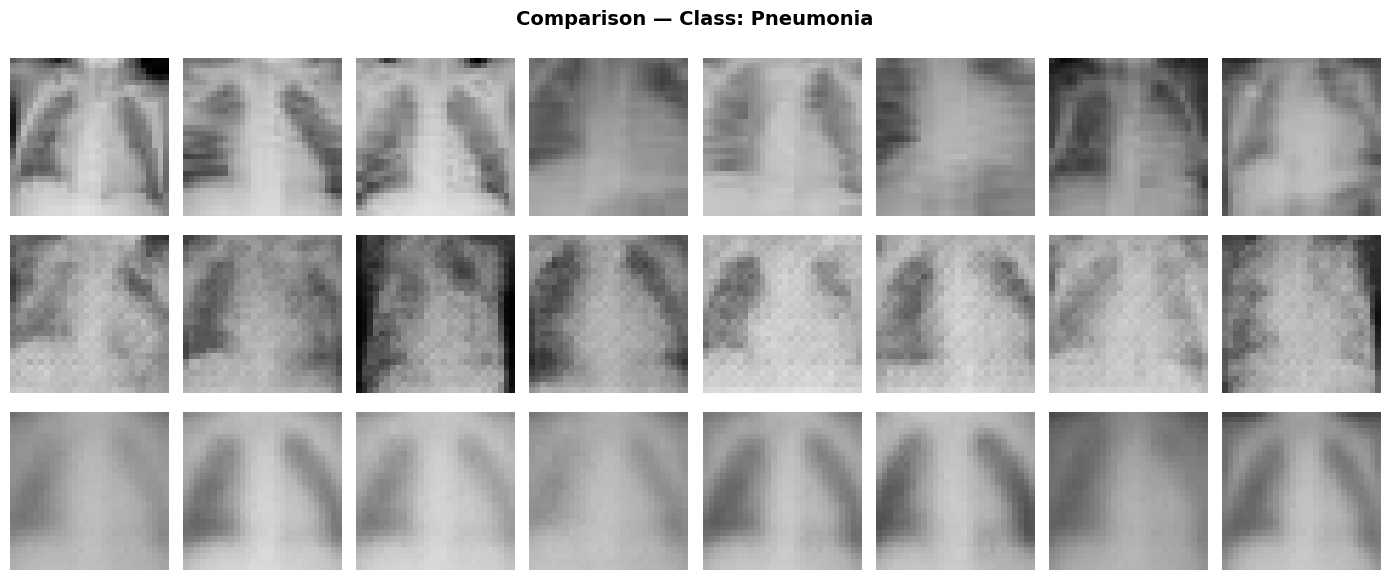

In [22]:
def display_comparison(label_val, class_name):
    """Side-by-side comparison: 8 Real / 8 GAN / 8 VAE images for one class."""
    real = get_real(train_gan, label_val, n=8)
    gan  = generate_gan(8, label_val)
    vae  = generate_vae(8, label_val)

    # 3 rows (Real, GAN, VAE) × 8 columns
    fig, axes = plt.subplots(3, 8, figsize=(14, 6))
    fig.suptitle(f'Comparison — Class: {class_name}', fontsize=14, fontweight='bold')

    # Zip rows with their image batches, row labels, and colors
    for row, (imgs, lbl, col) in enumerate([
        (real, 'Real',  'gray'),
        (gan,  'GAN',  'steelblue'),
        (vae,  'VAE',  'purple')
    ]):
        for c in range(8):
            # .squeeze() removes channel dim for imshow: (1,28,28) → (28,28)
            axes[row, c].imshow(imgs[c].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
            axes[row, c].axis('off')
        # Add row label on leftmost column only, rotated vertically
        axes[row, 0].set_ylabel(lbl, color=col, fontsize=11, rotation=90, labelpad=10)

    plt.tight_layout()
    plt.show()

# Run comparison for both classes
display_comparison(0, 'Normal')
display_comparison(1, 'Pneumonia')

## Inferences
Just looking at the trained outputs in comparing the GANs and the VAE reconstructed images, we can visually see that the second-row (GAN-reconstructed images) has sharper images in both the normal images and the pneumonia images, while the third-row (VAE-reconstructed images) created blurrier image — when both trained for 50 epochs.

The training time needed for GAN was significantly higher (around 25 minutes for GAN and 12 minutes for VAE for me) which was the effect from the inherent structure of each algorithm.

For further downstream classification tasks, both of the outputs here might suit different objectives:

- If sharpness of the image matters, i.e. visual inspection or anomaly detection, then the GAN sharper outputs are more useful.
- If you are using image as regulariser for classification, the blurry image in the current VAE could also be used as well.